# <b>Lec06. 회귀모델 - 집값예측
* <b>https://www.kaggle.com/datasets/vikrishnan/boston-house-prices

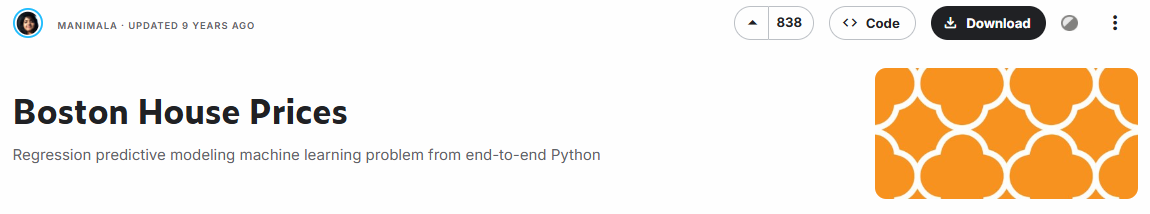

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LinearRegression            # 선형모델 : 회귀
#from sklearn.linear_model import LogisticRegression         # 선형모델 : 분류
from sklearn.tree import DecisionTreeRegressor               # 트리모델
from sklearn.ensemble import RandomForestRegressor           # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMRegressor                           # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBRegressor 
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Lasso 
from sklearn.linear_model import ElasticNet

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import mean_squared_error

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold   #, StratifiedKFold XXXXXX
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

#-----------------------------------------------------------------------------------  파이프라인
from sklearn.pipeline import Pipeline


import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

## 회귀모델
* 기울기 == 가중치 == 회귀계수(coef)
* 절편 == 바이어스 == 인터셉트

```python

sklearn.linear_model.Lasso(alpha=1.0, *, fit_intercept=True, random_state=None, max_iter=1000, tol=0.0001, precompute=False, copy_X=True, warm_start=False, positive=False, selection='cyclic')

sklearn.linear_model.Ridge(alpha=1.0, *, fit_intercept=True, random_state=None, max_iter=None, tol=0.0001, solver='auto', copy_X=True, positive=False)

sklearn.linear_model.ElasticNet(alpha=1.0, *,fit_intercept=True, random_state=None,  max_iter=1000, tol=0.0001, l1_ratio=0.5, precompute=False, copy_X=True, warm_start=False, positive=False, selection='cyclic')


<font color=red size=5>★★★★★★★★★★★★★★★★★★★★★★★★★★

## <font color=red size=5><b>규제(Regularization)

<B>L1 : Lasso : $  Error=MSE+α\sum_{i=1}^{n}{|w_i|} $

<B>L2 : Ridge : $  Error=MSE+α\sum_{i=1}^{n} w_i^2 $

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FcwyruE%2Fbtr3IDWa4ej%2FAAAAAAAAAAAAAAAAAAAAAMpr9-zufdhWelWTSaqo7AHPDqRJSh_r-zeJvX__7MaI%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1772290799%26allow_ip%3D%26allow_referer%3D%26signature%3D5ygOPKJX%252FhmDgRPd2bLHkuD9Yp4%253D" width=500>

<img src="https://qph.cf2.quoracdn.net/main-qimg-47e35df47f8539c6460ca450daa3f0da-lq" width=400>

<pre>
<b>* 설명 가능 수치일 경우   : [R] Regression  [E] Explained
* 설명 불가능 수치일 경우 : [R] Residual    [E] Error

* <b><font color=blue>SST(Total Sum of Squares) : 전체제곱합</font></b>
    - 관측값에서 관측값의 평균(혹은 추정치의 평균)을 뺀 결과의 총합인 총 제곱합
    - 전체(Total)에 대한 변동성
    - $ SST = SSR + SSE $
    - $ SST = \sum_{i=1}^{n} (y_i - \bar{y})^2 $ <br><br>
     
* <b><font color=blue><b>SSR(Sum of Squares due to Regression) : 회귀제곱합</font></b>
    - SSR(Sum of Squares due to Regression)
    - ESS(Explained Sum of Squares)
    - 예측값에서 관측값(y)의 평균(혹은 추정치의 평균)을 뺀 결과의 총합
    - 분석을 통해 설명 가능한 수치 
    - 직선(Regression)에 대한 변동성
    - $ SSR = \sum_{i=1}^{n} (\hat{y}_i - \bar{y})^2 $  <br><br>

* <b><font color=blue><b>SSE(Sum of Squares Residual of Error) : 잔차 제곱합</font></b>
    - SSE(Sum of Squares Residual of Error)
    - SSR(Sum of Squared Residual)
    - RSS(Residual sum of squares)
    - 잔차(실값-예측값) 제곱의 합
        - $ SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $ <br><br>
    - 잔차(실값-예측값) 제곱의 합의 평균
        - $ MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $ <br><br>
    - 편차(실값-평균값) 제곱의 합의 평균
        - $ 분산 = \frac{1}{n}\sum_{i=1}^{n} (y_i - \bar{y}_i)^2 $ <br><br>

* <b><font color=blue><b>$ R^2 $ : 결정계수</font></b>
    - 총 변동 중 설명 가능한 변동의 비율
    - $ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $
    - $r^2$ : 피어슨 상관계수<br><br>

* <b><font color=blue><b>설명된 분산 비율 (Explained Variance Ratio, PCA)</font></b>
    - 주성분 분석(PCA, Principal Component Analysis)
    - $\text{Explained Variance} = 1 - \frac{\mathrm{Var}(y - \hat{y})}{\mathrm{Var}(y)}$

## 평가 메트릭스

<table class="docutils align-default">
<thead>
<tr class="row-odd"><th class="head"><p>Scoring</p></th>
<th class="head"><p>Function</p></th>
<th class="head"><p>Comment</p></th>
</tr>
</thead>
<tbody>
<tr class="row-even"><td><p><strong>Regression</strong></p></td>
<td></td>
<td></td>
</tr>
<tr class="row-odd"><td><p>‘explained_variance’</p></td>
<td><p><a class="reference internal" href="generated/sklearn.metrics.explained_variance_score.html#sklearn.metrics.explained_variance_score" title="sklearn.metrics.explained_variance_score"><code class="xref py py-func docutils literal notranslate"><span class="pre">metrics.explained_variance_score</span></code></a></p></td>
<td></td>
</tr>
<tr class="row-odd"><td><p>‘neg_mean_absolute_error’</p></td>
<td><p><a class="reference internal" href="generated/sklearn.metrics.mean_absolute_error.html#sklearn.metrics.mean_absolute_error" title="sklearn.metrics.mean_absolute_error"><code class="xref py py-func docutils literal notranslate"><span class="pre">metrics.mean_absolute_error</span></code></a></p></td>
<td></td>
</tr>
<tr class="row-even"><td><p>‘neg_mean_squared_error’</p></td>
<td><p><a class="reference internal" href="generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error" title="sklearn.metrics.mean_squared_error"><code class="xref py py-func docutils literal notranslate"><span class="pre">metrics.mean_squared_error</span></code></a></p></td>
<td></td>
</tr>
<tr class="row-odd"><td><p>‘neg_root_mean_squared_error’</p></td>
<td><p><a class="reference internal" href="generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error" title="sklearn.metrics.mean_squared_error"><code class="xref py py-func docutils literal notranslate"><span class="pre">metrics.mean_squared_error</span></code></a></p></td>
<td></td>
</tr>
<tr class="row-even"><td><p>‘neg_mean_squared_log_error’</p></td>
<td><p><a class="reference internal" href="generated/sklearn.metrics.mean_squared_log_error.html#sklearn.metrics.mean_squared_log_error" title="sklearn.metrics.mean_squared_log_error"><code class="xref py py-func docutils literal notranslate"><span class="pre">metrics.mean_squared_log_error</span></code></a></p></td>
<td></td>
</tr>
<tr class="row-even"><td><p>‘r2’</p></td>
<td><p><a class="reference internal" href="generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score" title="sklearn.metrics.r2_score"><code class="xref py py-func docutils literal notranslate"><span class="pre">metrics.r2_score</span></code></a></p></td>
<td></td>
</tr>
</tbody>
</table>

### 📊 회귀 모델 평가 지표 총정리

| 지표 (Metric) | 전체 이름 (Full Name) | 핵심 별명 & 의미 | 이상치(Outlier) 반응 | 추천 활용 사례 (Business Case) |
| :--- | :--- | :--- | :--- | :--- |
| **MAE** | Mean Absolute Error | **"공정한 판사"**<br>오차의 절댓값 평균 | **둔감함 (Robust)**<br>큰 실수도 1/N로 취급 | 이상치가 많아서 이를 무시하고 **평균적인 경향**을 보고 싶을 때.<br>(예: 배달 시간, 일반적인 매출 추이) |
| **MSE** | Mean Squared Error | **"수학 오타쿠"**<br>오차의 제곱 평균 | **민감함**<br>큰 오차를 제곱으로 뻥튀기 | **모델 내부 학습용(Loss Function)**.<br>단위가 제곱($원^2$)이라 사람이 보고용으로 쓰기는 힘듦. |
| **RMSE** | Root Mean Squared Error | **"호랑이 선생님"**<br>MSE에 루트를 씌움 | **민감함 (Penalty)**<br>큰 실수에 가중 처벌 | **가장 대중적인 표준 지표**.<br>단 한 번의 큰 사고(오차)도 막아야 하는 경우.<br>(예: 자율주행, 의료, 금융 예측) |
| **MSLE** | Mean Squared Log Error | **"비율 계산기"**<br>로그 변환 후 오차 계산 | **큰 값에 둔감**<br>비율(%) 차이를 봄 | 1. **과소 예측(Under-estimation)을 더 엄벌**해야 할 때.<br>(예: 자전거 수요, 재고 관리 - 모자라면 큰일 남)<br>2. 데이터 값의 **스케일 차이**가 너무 클 때 (1억 vs 100억). |
| **R²** | R-Squared | **"상대 평가 점수"**<br>결정 계수 (0~1) | - | 에러 양이 아니라 **"모델의 설명력(%)"**을 과시할 때.<br>데이터 단위가 다른 모델끼리 성능을 비교할 때. |

$ \mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 $<br>
 : 오차에 민감<br>
 
$ \mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2} $  = $\sqrt{MSE} $<br>         : 가장 해석하기 쉬운 원수치 오차 <br>

$ \mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}\lvert y_i - \hat{y}_i \rvert $<br>
  : 직관적, 절대값(크기) 오차<br>
  
$ \mathrm{MSLE} = \frac{1}{n}\sum_{i=1}^{n} \left( \log(1 + y_i) - \log(1 + \hat{y}_i) \right)^2 $<br>
 : 차이값 보다는 비율을 중요시, 작은값의 실수에 민감한 경우(ex:금리, 성장률..)

# <B>Data Load

<pre>
속성	 설명
---------------------------------
CRIM	 범죄율
ZN       25,000 평방피트를 초과 거주지역 비율
INDUS	 비소매상업지역 면적 비율
CHAS	 찰스강의 경계에 위치 유무(경계위치1, 아닌경우0)
NOX      일산화질소 농도
RM       주택당 방 수
AGE      1940년 이전에 건축된 주택의 비율
DIS      직업센터의 거리
RAD      방사형 고속도로까지의 거리
TAX      재산세율
PTRATIO	 학생/교사 비율
B        인구 중 흑인 비율
LSTAT	 인구 중 하위 계층 비율

In [2]:
df = pd.read_csv("./data/lec06_boston-house-price-data.csv")
df.columns = df.columns.str.lower()
df.info()

FileNotFoundError: [Errno 2] No such file or directory: './data/lec06_boston-house-price-data.csv'

In [ ]:
df.head(2)

# <b>EDA

## 분포도 : histogram

In [ ]:
plt.figure(figsize=(10,5))
df.hist()
plt.tight_layout()
plt.show()

## 상관계수 : heatmap 
* 피어슨(Pearson) 상관계수 : 선형  --> 히트맵은 기본이 선형
* 스피어만(Spearman) 상관계수 : 비선형

In [ ]:
plt.figure(figsize=(12, 3))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt=".2f", mask=mask, cmap='coolwarm') 
plt.show()

* <b>(+)target : RM(LSTAT) ZN(DIS) B
* <b>(-)target : LSTAT INDUS(..) TAX(LSTAT PTRATIO) NOX(AGE TAX DIS LSTAT)
* <b>rad. tax : 0.91

## 컬럼 유니크 확인
* 각 컬럼별 유니크값 개수, 해당 유니크값[:10] 출력
* 연속형, 이산형(범주형) 피쳐 판단 목적
* CHAS RAD 

In [ ]:
for col in df.columns:
    print(f"{col} \t{df[col].nunique()} \t{df[col].unique()[:8]}") 

#  ⬮ 1차 점수 : 우선 점수부터 보자

In [ ]:
y = df['medv']
X = df.drop('medv', axis=1)
print(X.shape,  y.shape)

X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )
print(X80.shape,X20.shape,y80.shape,y20.shape)
model_list = [ LinearRegression()
               , DecisionTreeRegressor(random_state=4567), RandomForestRegressor(random_state=4567)
               , XGBRegressor(random_state=4567) , LGBMRegressor(random_state=4567, verbosity=-1)
               , Lasso(random_state=4567), Ridge(random_state=4567)
             ]
for model in model_list:
    print(f" {model.__class__.__name__} --------------------" )  
    model.fit(X80, y80)
    pred  = model.predict(X20)
    
    mse       = mean_squared_error(y20        , pred)
    rmse      = np.sqrt(mse)
    print(f"mse:{mse:.4f}\t rmse:{rmse:.4f}")
    print()

In [ ]:
def myscore(df) :
    y = df['medv']
    X = df.drop('medv', axis=1)
    print(X.shape,  y.shape)
    
    X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )
    print(X80.shape,X20.shape,y80.shape,y20.shape)
    model_list = [ LinearRegression()
                   , DecisionTreeRegressor(random_state=4567), RandomForestRegressor(random_state=4567)
                   , XGBRegressor(random_state=4567) , LGBMRegressor(random_state=4567, verbosity=-1)
                   , Lasso(random_state=4567), Ridge(random_state=4567)
                 ]
    for model in model_list:
        print(f" {model.__class__.__name__} --------------------" )  
        model.fit(X80, y80)
        pred  = model.predict(X20)
        
        mse       = mean_squared_error(y20        , pred)
        rmse      = np.sqrt(mse)
        
        print(f"mse:{mse:.4f}\t rmse:{rmse:.4f}")
        print()

# <b>전처리 & 가공
* Feature Engineering

## 왜도 & 첨도

| 상태     | 왜도         | 첨도     |
| ------ | ---------- | ------ |
| 거의 정규  | -0.5 ~ 0.5 | -1 ~ 1 |
| 실무 허용  | -1 ~ 1     | -2 ~ 2 |
| 비정규 의심 | ±1 초과      | ±2 초과  |


In [ ]:
plt.figure(figsize=(6,1))
plt.subplot(1,2,1)
df['medv'].hist()
plt.title(f"왜도{df['medv'].skew():.2f}  첨도{df['medv'].kurtosis():.2f}  ")

plt.subplot(1,2,2)
np.log1p(df['medv']).hist()
plt.title(f"왜도{np.log1p(df['medv']).skew():.2f}  첨도{np.log1p(df['medv']).kurtosis():.2f}  ")

plt.show()

chas rad

In [ ]:
df.columns


In [ ]:
skdf = pd.DataFrame()
col_list = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax','ptratio', 'b', 'lstat', 'medv']
skdf['col']  = col_list
skdf['skew'] = df[col_list].skew().values
skdf['kurt'] = df[col_list].kurt().values

#skdf.sort_values(by="skew",  key=lambda x: x.abs(), ascending=False)  #(왼+) :insulin , dpf,     (오:-)bpress
skdf.sort_values(by="kurt",  key=lambda x: x.abs(), ascending=False)   #insulin , bpress,  dpf,  bmi

* 왜도 / 첨도 ['crim', 'b' , 'zn']

## 로그  + 스케일링

### ⬮ 2차점수 : 연속형 모든 피쳐 

In [ ]:
dfcp = df.copy()

In [ ]:
col_list = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax','ptratio', 'b', 'lstat', 'medv']
dfcp[col_list] = np.log1p(dfcp[col_list])
dfcp.head(2)

In [ ]:
from sklearn.pipeline import Pipeline

y = dfcp['medv']
X = dfcp.drop('medv', axis=1)

X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])    
pipeline.fit(X80, y80)
pred = pipeline.predict(X20)

mse       = mean_squared_error(np.expm1(y20) ,np.expm1(pred))
rmse      = np.sqrt(mse)
print(f"mse:{mse:.4f}\t rmse:{rmse:.4f}") 

In [ ]:
model_list = [ LinearRegression()
               , DecisionTreeRegressor(random_state=4567), RandomForestRegressor(random_state=4567)
               , XGBRegressor(random_state=4567) , LGBMRegressor(random_state=4567, verbosity=-1)
               , Lasso(random_state=4567), Ridge(random_state=4567)
             ]
for model in model_list:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', model)
    ])    
    pipeline.fit(X80, y80)
    pred = pipeline.predict(X20)
    
    mse       = mean_squared_error(np.expm1(y20), np.expm1(pred))
    rmse      = np.sqrt(mse)
    print(f"mse:{mse:.4f}\t rmse:{rmse:.4f} \t {model.__class__.__name__}")

### ⬮ 3차점수 : 왜도&첨도 심한 피쳐만

In [ ]:
dfcp = df.copy()

In [ ]:
col_list = ['crim', 'zn', 'b',  'medv']
dfcp[col_list] = np.log1p(dfcp[col_list])
#dfcp.head(2)

y = dfcp['medv']
X = dfcp.drop('medv', axis=1)
X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )

odel_list = [ LinearRegression()
               , DecisionTreeRegressor(random_state=4567), RandomForestRegressor(random_state=4567)
               , XGBRegressor(random_state=4567) , LGBMRegressor(random_state=4567, verbosity=-1)
               , Lasso(random_state=4567), Ridge(random_state=4567)
             ]
for model in model_list:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', model)
    ])    
    pipeline.fit(X80, y80)
    pred = pipeline.predict(X20)
    
    mse       = mean_squared_error(np.expm1(y20), np.expm1(pred))
    rmse      = np.sqrt(mse)
    print(f"mse:{mse:.4f}\t rmse:{rmse:.4f} \t {model.__class__.__name__}")

## 다중공선
* rad. tax : 0.91
* 삭제 : 타켓에 영향도가 적다 or 다른 피쳐와의 영향도가 적다
* PCA(차원축소)
* 합쳐라 - XXXX(피쳐의 성격이 다름)

### ⬮ 4차점수 : 삭제

In [ ]:
dfcp = df.copy()
dfcp = dfcp.drop('rad', axis=1)

In [ ]:
col_list = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax','ptratio', 'b', 'lstat', 'medv']
dfcp[col_list] = np.log1p(dfcp[col_list])
#dfcp.head(2)

y = dfcp['medv']
X = dfcp.drop('medv', axis=1)
X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )

model_list = [ LinearRegression()
               , DecisionTreeRegressor(random_state=4567), RandomForestRegressor(random_state=4567)
               , XGBRegressor(random_state=4567) , LGBMRegressor(random_state=4567, verbosity=-1)
               , Lasso(random_state=4567), Ridge(random_state=4567)
             ]
for model in model_list:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', model)
    ])    
    pipeline.fit(X80, y80)
    pred = pipeline.predict(X20)
    
    mse       = mean_squared_error(np.expm1(y20), np.expm1(pred))
    rmse      = np.sqrt(mse)
    print(f"mse:{mse:.4f}\t rmse:{rmse:.4f} \t {model.__class__.__name__}")

### 차원축소 (PCA)

```python
sklearn.decomposition.PCA(n_components=None, random_state=None, *, copy=True, whiten=False, svd_solver='auto', tol=0.0, iterated_power='auto', n_oversamples=10, power_iteration_normalizer='auto')

In [ ]:
dfcp = df.copy()

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=1, random_state=4878)
dfcp['tax-rad'] = pca.fit_transform(dfcp[['tax', 'rad']])
print(pca.explained_variance_ratio_)
dfcp.head(2)

* <font color=red><b>PCA 후 음수값 생김 --> log변환 불가

## 아웃라이어

In [ ]:
dfcp = df.copy()

In [ ]:
plt.figure(figsize=(4, 2))
sns.scatterplot(x="tax", y="rad", data=dfcp)      #---------------------------- sns        산점도
plt.title("tax rad")
plt.show()

## ⬮ 5차점수 

In [ ]:
drop_index = dfcp[dfcp['tax']>600].index
drop_index

In [ ]:
print(dfcp.shape)
dfcp = dfcp.drop(drop_index , axis=0 )
print(dfcp.shape)

In [ ]:
col_list = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax','ptratio', 'b', 'lstat', 'medv']
dfcp[col_list] = np.log1p(dfcp[col_list])
#dfcp.head(2)

y = dfcp['medv']
X = dfcp.drop('medv', axis=1)
X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )

model_list = [ LinearRegression()
               , DecisionTreeRegressor(random_state=4567), RandomForestRegressor(random_state=4567)
               , XGBRegressor(random_state=4567) , LGBMRegressor(random_state=4567, verbosity=-1)
               , Lasso(random_state=4567), Ridge(random_state=4567)
             ]
for model in model_list:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', model)
    ])    
    pipeline.fit(X80, y80)
    pred = pipeline.predict(X20)
    
    mse       = mean_squared_error(np.expm1(y20), np.expm1(pred))
    rmse      = np.sqrt(mse)
    print(f"mse:{mse:.4f}\t rmse:{rmse:.4f} \t {model.__class__.__name__}")

* <font color=red><b> 아웃라이어 삭제 --> 로그변환 --> 스케일링   : 선형 모델은 성능이 좋아졌다

# 규제 중심

## 선형모델

In [ ]:
#df         # 원본
dfcp.shape  # 아웃라이어 삭제 - 로그변환 - 스케일링

In [ ]:
y = dfcp['medv']
X = dfcp.drop('medv', axis=1)
X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )

model_list = [  LinearRegression(), Lasso(random_state=4567, alpha=0.1), Ridge(random_state=4567) ]

plt.figure(figsize=(15, 4))
for i, model in enumerate(model_list):
    model.fit(X80, y80)

    # ---------------------------------------
    # coef 바차트 (subplot)
    # ---------------------------------------
    coef = model.coef_         #----회귀계수 == 가중치 == 기울기
    feature_names = X.columns

    idx = np.argsort(np.abs(coef))[::-1]  # 영향도 기준 정렬 (절댓값)

    plt.subplot(1, 3, i + 1)
    plt.barh(feature_names[idx], coef[idx])
    plt.axvline(0, linestyle='--', linewidth=1)
    plt.gca().invert_yaxis()
    plt.title(model.__class__.__name__)
    plt.xlabel("Coefficient")

    # ---------------------------------------
    # 성능 평가
    # ---------------------------------------
    pred = model.predict(X20)
    mse  = mean_squared_error(np.expm1(y20), np.expm1(pred))
    rmse = np.sqrt(mse)

    print(f"mse:{mse:.4f}\t rmse:{rmse:.4f}\t {model.__class__.__name__}")

plt.tight_layout()
plt.show()

## 트리모델

In [ ]:
fig = plt.figure(figsize=(12, 4))

model_list = [XGBRegressor(random_state=4567) , LGBMRegressor(random_state=4567, verbosity=-1)]

for i, model in enumerate(model_list):
    model.fit(X80, y80)

    # --------------------------------------- 피쳐중요도 차트 (subplot)
    importances = model.feature_importances_
    feature_names = X.columns
    idx = np.argsort(importances)[::-1]
    plt.subplot(1, 2, i+1)
    plt.barh(feature_names[idx], importances[idx])
    plt.gca().invert_yaxis()
    plt.title(f"{model.__class__.__name__}")
    plt.xlabel("Importance")

    # --------------------------------------- 성능 평가
    pred = model.predict(X20)
    mse  = mean_squared_error(np.expm1(y20), np.expm1(pred))
    rmse = np.sqrt(mse)
    print(f"mse:{mse:.4f}\t rmse:{rmse:.4f}\t {model.__class__.__name__}")

plt.tight_layout()
plt.show()


``` python
classlightgbm.LGBMRegressor(*, boosting_type='gbdt', num_leaves=31, max_depth=-1, learning_rate=0.1, n_estimators=100, subsample_for_bin=200000, objective=None, class_weight=None, min_split_gain=0.0, min_child_weight=0.001, min_child_samples=20, subsample=1.0, subsample_freq=0, colsample_bytree=1.0, reg_alpha=0.0, reg_lambda=0.0, random_state=None, n_jobs=None, importance_type='split', **kwargs)

## ⬮ 6차점수 : 규제 튜닝

In [ ]:
y = dfcp['medv']
X = dfcp.drop('medv', axis=1)
X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )

alpha_list = [0.01, 0.1 , 1.0 , 10.0]
for MY_ALPHA in alpha_list:    
    model_list = [   Lasso(random_state=4567, alpha=MY_ALPHA) 
                   , Ridge(random_state=4567, alpha=MY_ALPHA) 
                 ]
    
    plt.figure(figsize=(15, 4))
    for i, model in enumerate(model_list):
        model.fit(X80, y80)
    
        # ---------------------------------------
        # coef 바차트 (subplot)
        # ---------------------------------------
        coef = model.coef_         #----회귀계수 == 가중치 == 기울기
        feature_names = X.columns
    
        idx = np.argsort(np.abs(coef))[::-1]  # 영향도 기준 정렬 (절댓값)
    
        plt.subplot(1, 2, i + 1)
        plt.barh(feature_names[idx], coef[idx])
        plt.axvline(0, linestyle='--', linewidth=1)
        plt.gca().invert_yaxis()
        plt.title(f" {model.__class__.__name__}  규제강도:{MY_ALPHA}")
        plt.xlabel("Coefficient")
    
        # ---------------------------------------
        # 성능 평가
        # ---------------------------------------
        pred = model.predict(X20)
        mse  = mean_squared_error(np.expm1(y20), np.expm1(pred))
        rmse = np.sqrt(mse)
    
        print(f"mse:{mse:.4f}\t rmse:{rmse:.4f}\t {model.__class__.__name__}")
    
    plt.tight_layout()
    plt.show()